## **Messwerte**

In [1]:
import numpy as np

g = 9.80665 #Erdbeschleunigung

m = 9.7e-3 #Masse des Schwingkörpers in kg
m_Fehler = 0.01e-3


d = 1.660e-2 #Durchmesser des Schwingrohrs in m
d_Fehler = 0.05e-3 #Messfehler für d


p_Umgebung = 1.024 * 10**5 #Umgebungsdruck in Pa
p_Umgebung_Fehler = 1e-3 * 10**5

d_Reservoir = 10.3e-2
d_Reservoir_Fehler = 0.4e-2

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Messungen zu Argon

V_Argon = np.array([2e-2 , 4e-2 , 6e-2 , 8e-2 , 10e-2 , 12e-2 , 14e-2 , 16e-2 , 18e-2 , 20e-2 ])*np.pi*(d_Reservoir / 2)**2  # Die 10 Gesamtvolumen des Gefäßes in m^3

T_Argon = np.array([ 5052 ,  5684 ,  6321  ,  6911  ,  7421  , 7954  ,  8360  , 8814   , 9200   ,  9602 ]) / (1000*30)

T_Argon_Fehler = 5e-3 /30

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Messungen zu Stickstoff

V_Stickstoff = np.array([2e-2 , 4e-2 , 6e-2 , 8e-2 , 10e-2 , 12e-2 , 14e-2 , 16e-2 , 18e-2 , 20e-2 ])*np.pi*(d_Reservoir / 2)**2 # Die 10 Gesamtvolumen des Gefäßes in m^3

T_Stickstoff = np.array([ 5015 ,  6207  , 6797 , 7493 , 7913 , 8120 , 8990 , 9260 , 10014 , 10476  ]) / (1000*30)

T_Stickstoff_Fehler = 5e-3 /30

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Messungen zu CO2

V_CO2 = np.array([2e-2 , 4e-2 , 6e-2 , 8e-2 , 10e-2 , 12e-2 , 14e-2 , 16e-2 , 18e-2 , 20e-2 ])*np.pi*(d_Reservoir / 2)**2 # Die 10 Gesamtvolumen des Gefäßes in m^3

T_CO2 = np.array([ 5583  ,  6449  ,  7156  ,  7794  ,  8443  ,  8797  , 9487  ,  10026  ,  10558  ,  11074  ]) / (1000*30)

T_CO2_Fehler = 5e-3 /30


## **Lineare Regression**

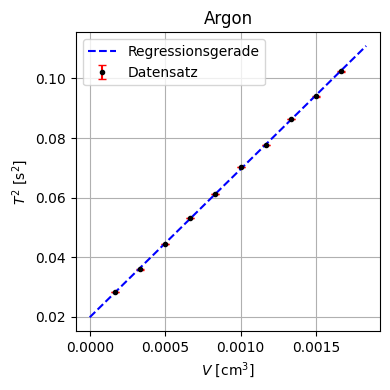

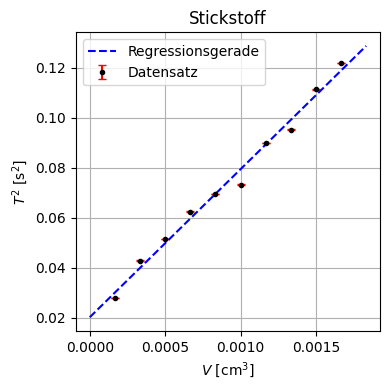

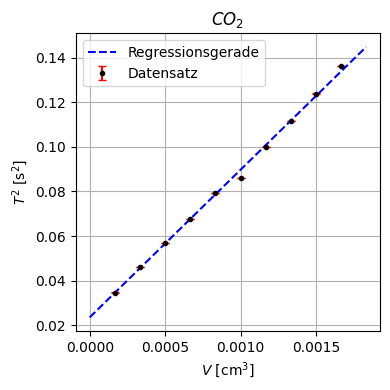

In [2]:
import matplotlib.pyplot as plt
import scipy
import sympy
from Skripte.Fehlerfortpflanzung import Gaußfehler
import matplotlib

"""
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'arial',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
"""

Tp = sympy.symbols("T")
expr0 = Tp**2
Variablen_0 = np.array([Tp])

def f(x,k,a):
    return k*x + a #Fit Funktion

fig, ax1 = plt.subplots(1,1, figsize = (4,4))



#Argon
T_Argon_quad = T_Argon**2

T_Argon_quad_Fehler = np.ones(10, dtype = float)

for i in range(0, len(T_Argon_quad)):
    T_Argon_quad_Fehler[i] = Gaußfehler(expr0, Variablen_0, np.array([T_Argon[i]]), np.array([T_Argon_Fehler]))

coefficients, pcov = scipy.optimize.curve_fit(f, V_Argon, T_Argon_quad, sigma = T_Argon_quad_Fehler, absolute_sigma=True)

k_Argon = coefficients[0] #Steigung der Regressionsgeraden
k_Argon_Fehler = np.sqrt(pcov[0,0])

ax1.errorbar(V_Argon, T_Argon_quad, yerr = T_Argon_quad_Fehler, fmt = "o", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

xwerte = np.linspace(0, np.max(V_Argon)*1.1, 500)
ax1.plot(xwerte, k_Argon*xwerte + coefficients[1], color = "blue", linestyle = "--", label = "Regressionsgerade")

ax1.set_xlabel("$V~[\\mathrm{cm^3}]$")
ax1.set_ylabel("$T^2~[\\mathrm{s^2]}$")
ax1.grid(True)
ax1.set_title("Argon")
ax1.legend()

plt.tight_layout()

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Stickstoff
fig, ax2 = plt.subplots(1,1, figsize = (4,4))

T_Stickstoff_quad = T_Stickstoff**2

T_Stickstoff_quad_Fehler = np.zeros(10, dtype = float)

for i in range(0, len(T_Stickstoff_quad)):
    T_Stickstoff_quad_Fehler[i] = Gaußfehler(expr0, Variablen_0, np.array([T_Stickstoff[i]]), np.array([T_Stickstoff_Fehler]))

coefficients, pcov = scipy.optimize.curve_fit(f, V_Stickstoff, T_Stickstoff_quad, sigma = T_Stickstoff_quad_Fehler, absolute_sigma=True)

k_Stickstoff = coefficients[0] #Steigung der Regressionsgeraden
k_Stickstoff_Fehler = np.sqrt(pcov[0,0])

ax2.errorbar(V_Stickstoff, T_Stickstoff_quad, yerr = T_Stickstoff_quad_Fehler, fmt = "o", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

xwerte = np.linspace(0, np.max(V_Stickstoff)*1.1, 500)
ax2.plot(xwerte, k_Stickstoff*xwerte + coefficients[1], color = "blue", linestyle = "--", label = "Regressionsgerade")

ax2.set_xlabel("$V~[\\mathrm{cm^3}]$")
ax2.set_ylabel("$T^2~[\\mathrm{s^2]}$")
ax2.grid(True)
ax2.set_title("Stickstoff")
ax2.legend()

plt.tight_layout()

"""-----------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#CO2
fig, ax3 = plt.subplots(1,1, figsize = (4,4))

T_CO2_quad = T_CO2**2

T_CO2_quad_Fehler = np.zeros(10, dtype = float)

for i in range(0, len(T_CO2_quad)):
    T_CO2_quad_Fehler[i] = Gaußfehler(expr0, Variablen_0, np.array([T_CO2[i]]), np.array([T_CO2_Fehler]))

coefficients, pcov = scipy.optimize.curve_fit(f, V_CO2, T_CO2_quad, sigma = T_CO2_quad_Fehler, absolute_sigma=True)

k_CO2 = coefficients[0] #Steigung der Regressionsgeraden
k_CO2_Fehler = np.sqrt(pcov[0,0])

ax3.errorbar(V_CO2, T_CO2_quad, yerr = T_CO2_quad_Fehler, fmt = "o", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

xwerte = np.linspace(0, np.max(V_CO2)*1.1, 500)
ax3.plot(xwerte, k_CO2*xwerte + coefficients[1], color = "blue", linestyle = "--", label = "Regressionsgerade")

ax3.set_xlabel("$V~[\\mathrm{cm^3}]$")
ax3.set_ylabel("$T^2~[\\mathrm{s^2]}$")
ax3.grid(True)
ax3.set_title("$CO_{2}$")
ax3.legend()

plt.tight_layout()


## **Berechnung der Adiabatenexponenten**

In [3]:

A = np.pi*(d/2)**2 #Querschnittsfläche des Schwingers in m^2

dp = sympy.symbols("d")
expr2 = sympy.pi * (dp/2)**2
display(expr2)

A_Fehler = Gaußfehler(expr2, np.array([dp]), np.array([d]), np.array([d_Fehler]))



p_Ruhe = p_Umgebung + m*g/A

pU, mp, Ap = sympy.symbols("p_0, m, A")
expr2 = pU + mp*g/Ap
display(expr2)

p_Ruhe_Fehler = Gaußfehler(expr2, np.array([pU, mp, Ap]), np.array([p_Umgebung, m, A]), np.array([p_Umgebung_Fehler, m_Fehler, A_Fehler]))



mp, kp, pR, Ap = sympy.symbols("m, k , p_Ruhe , A ")
expr3 = (4*sympy.pi**2*mp) / (kp*pR*Ap**2)
display(expr3)
Variablen_3 = np.array([mp, kp, pR, Ap])

kappa_Argon = (4*np.pi**2*m) / (k_Argon*p_Ruhe*A**2)
kappa_Argon_Fehler = Gaußfehler(expr3, Variablen_3, np.array([m, k_Argon, p_Ruhe, A]), np.array([m_Fehler, k_Argon_Fehler, p_Ruhe_Fehler, A_Fehler]))

kappa_Stickstoff = (4*np.pi**2*m) / (k_Stickstoff*p_Ruhe*A**2)
kappa_Stickstoff_Fehler = Gaußfehler(expr3, Variablen_3, np.array([m, k_Stickstoff, p_Ruhe, A]), np.array([m_Fehler, k_Stickstoff_Fehler, p_Ruhe_Fehler, A_Fehler]))

kappa_CO2 = (4*np.pi**2*m) / (k_CO2*p_Ruhe*A**2)
kappa_CO2_Fehler = Gaußfehler(expr3, Variablen_3, np.array([m, k_CO2, p_Ruhe, A]), np.array([m_Fehler, k_CO2_Fehler, p_Ruhe_Fehler, A_Fehler]))

print(f"\n kappa für Argon (soll: 1.67): kappa = {kappa_Argon} +/- {kappa_Argon_Fehler}")
print(f"\n kappa für Stickstoff (soll: 1.4) : kappa = {kappa_Stickstoff} +/- {kappa_Stickstoff_Fehler}")
print(f"\n kappa für Co2: kappa (soll: Soll: 1.3) = {kappa_CO2} +/- {kappa_CO2_Fehler}")


hp, dp = sympy.symbols("h, d")
expr3 = sympy.pi * (dp/2)**2 * hp
display(expr3)
V_Fehler = np.ones(10, dtype=float)

for i in range(0,10):
    V_Fehler[i] = Gaußfehler(expr3, np.array([hp,dp]), np.array([d_Reservoir, V_Stickstoff[i]]), np.array([0.5e-3, d_Reservoir_Fehler]))

from Skripte.Fehlerfortpflanzung import VisualGaußfehler

gamma, m, g, p_L, k, d = sympy.symbols('gamma m g p_L k d')

formel = (64 * m) / ((p_L + (m * g) / (sympy.pi * (d / 2)**2)) * k * d**4)

display(VisualGaußfehler(formel, np.array([m, g, p_L, k, d])))


pi*d**2/4

p_0 + 9.80665*m/A

4*pi**2*m/(A**2*k*p_Ruhe)


 kappa für Argon (soll: 1.67): kappa = 1.5988090790936846 +/- 0.019470306229270883

 kappa für Stickstoff (soll: 1.4) : kappa = 1.3412434727065534 +/- 0.016319998546670118

 kappa für Co2: kappa (soll: Soll: 1.3) = 1.2004456099190774 +/- 0.014603481928734847


pi*d**2*h/4

sqrt(Delta_d**2*(-256*m/(d**5*k*(p_L + 4*g*m/(pi*d**2))) + 512*g*m**2/(pi*d**7*k*(p_L + 4*g*m/(pi*d**2))**2))**2 + 65536*Delta_g**2*m**4/(pi**2*d**12*k**2*(p_L + 4*g*m/(pi*d**2))**4) + 4096*Delta_k**2*m**2/(d**8*k**4*(p_L + 4*g*m/(pi*d**2))**2) + Delta_m**2*(64/(d**4*k*(p_L + 4*g*m/(pi*d**2))) - 256*g*m/(pi*d**6*k*(p_L + 4*g*m/(pi*d**2))**2))**2 + 4096*Delta_p_L**2*m**2/(d**8*k**2*(p_L + 4*g*m/(pi*d**2))**4))